In [1]:
import os 
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

2025-02-27 11:57:57.541841: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-27 11:57:58.205696: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1740657478.449501    1677 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1740657478.518173    1677 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-27 11:57:59.144251: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

## Creating tf dataset

In [2]:
dataset_dir = "./Skin cancer ISIC The International Skin Imaging Collaboration/"

train_dir = os.path.join(dataset_dir,'Train')
test_dir = os.path.join(dataset_dir,'Test')
BATCH_SIZE = 32

IMAGE_HEIGHT = 256
IMAGE_WIDTH = 256


train_dataset = tf.keras.utils.image_dataset_from_directory( directory= train_dir,
                                                             shuffle= True,
                                                            batch_size= BATCH_SIZE,
                                                            image_size= (IMAGE_HEIGHT,IMAGE_WIDTH),
                                                            seed= 142)

test_dataset = tf.keras.utils.image_dataset_from_directory( directory= test_dir,
                                                             shuffle= True,
                                                            batch_size= BATCH_SIZE,
                                                            image_size= (IMAGE_HEIGHT,IMAGE_WIDTH),
                                                            seed= 142)
                                                        

Found 2239 files belonging to 9 classes.


I0000 00:00:1740657485.772561    1677 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13949 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:1e.0, compute capability: 7.5


Found 118 files belonging to 9 classes.


In [3]:
class_names = train_dataset.class_names
class_names

['actinic keratosis',
 'basal cell carcinoma',
 'dermatofibroma',
 'melanoma',
 'nevus',
 'pigmented benign keratosis',
 'seborrheic keratosis',
 'squamous cell carcinoma',
 'vascular lesion']

## Let's visualize images we have

2025-02-27 11:58:08.081744: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


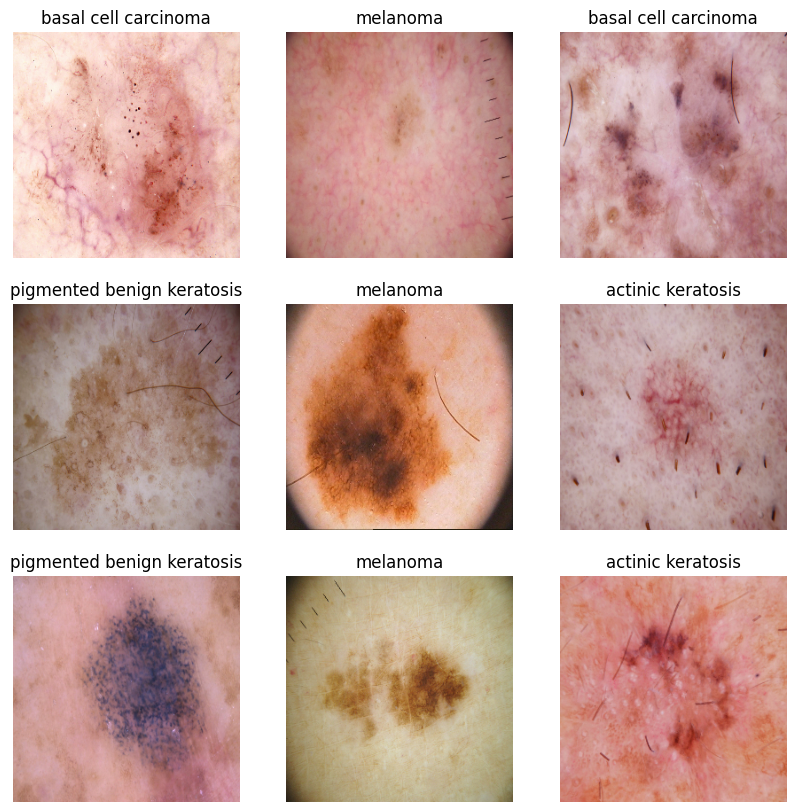

In [4]:
plt.figure(figsize=(10,10))

# NOTE : dataset.take(1) results one batch of (images,labels)
for images,labels in train_dataset.take(1):
     for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype(np.uint16))
        plt.title(class_names[labels[i]])
        plt.axis("off")
    

## Resizing and rescaling images

In [11]:
preprocessing_layer = tf.keras.Sequential([
        tf.keras.layers.Resizing(IMAGE_HEIGHT,IMAGE_WIDTH),
        tf.keras.layers.Rescaling(1./255),      
])

# Augmenting Image

In [12]:
augmentation_layer = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal_and_vertical",input_shape=(IMAGE_HEIGHT,IMAGE_WIDTH,3)),
  tf.keras.layers.RandomRotation(0.2),
  tf.keras.layers.RandomZoom(0.1),
])

## Lets visualize an augmented image

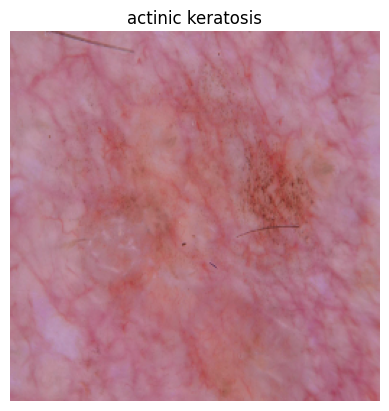

In [13]:
random_i = tf.keras.random.randint((),0,len(images))
test_image = images[random_i].numpy().astype(np.uint16)
plt.imshow(test_image)
plt.title(class_names[labels[random_i]])
plt.axis('off')
plt.show()

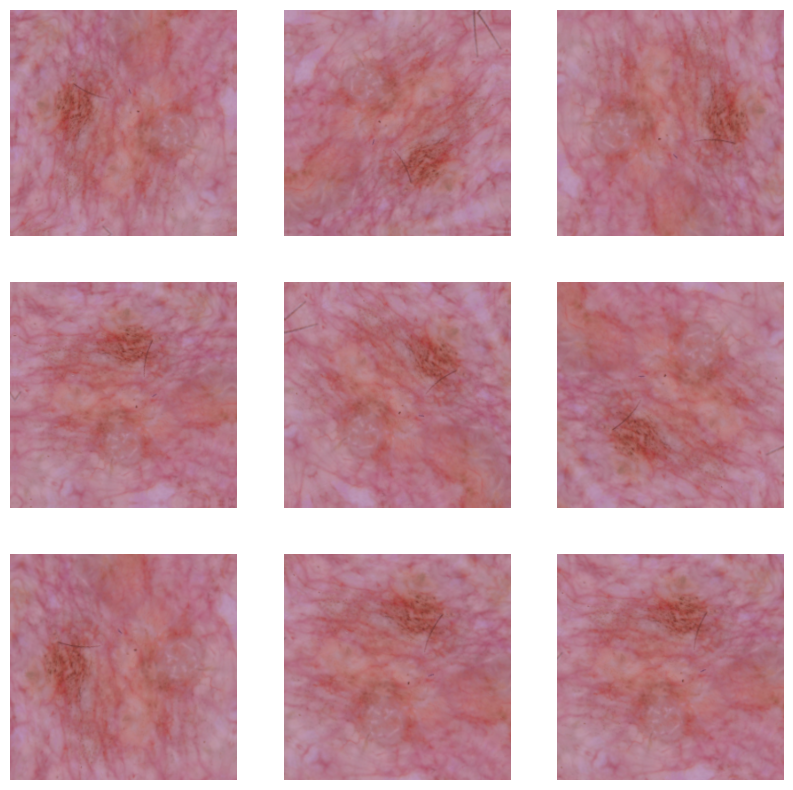

In [14]:
plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    augmented_image = augmentation_layer(tf.expand_dims(test_image, 0))
    plt.imshow(augmented_image[0] / 255)
    plt.axis('off')

### Using buffered prefetching, helps you yield data from disk without having I/O become blocking.

In [15]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE) 
test_dataset= test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

## Defining the model

In [24]:
class Model_1(tf.keras.Model):

    def __init__(self, number_of_classes : int ):
        super().__init__()
        self.conv_layer1 = tf.keras.layers.Conv2D(32, 3)
        self.conv_layer2 = tf.keras.layers.Conv2D(64, 3 )
        self.conv_layer3 = tf.keras.layers.Conv2D(64, 3 )
        self.conv_layer4 = tf.keras.layers.Conv2D(128, 3 )
        self.conv_layer5 = tf.keras.layers.Conv2D(512, 3 )

        self.activation_relu = tf.keras.layers.Activation("relu")

        self.batch_normalization = tf.keras.layers.BatchNormalization()
        self.max_pool_layer = tf.keras.layers.MaxPool2D()
        self.avg_pool_layer = tf.keras.layers.AveragePooling2D(pool_size=(2,2))

        self.dropout = tf.keras.layers.Dropout(0.4)
        self.batch_normalization = tf.keras.layers.BatchNormalization()
        self.flatten_layer = tf.keras.layers.Flatten()
        self.dense_mid = tf.keras.layers.Dense(128,activation="relu")
        self.output_dense = tf.keras.layers.Dense(number_of_classes)
        

    def call(self, x):

        x = preprocessing_layer(x)
        x = augmentation_layer(x)
        
        # First Convolution
        x = self.conv_layer1(x)
        # x = self.batch_normalization(x)
        x = self.activation_relu(x)
        # x = self.avg_pool_layer(x)
    

        # Second Convolution
        x = self.conv_layer2(x)
        x = self.activation_relu(x)
        # x = self.batch_normalization(x)
        x = self.max_pool_layer(x)


        x = self.conv_layer3(x)
        x = self.activation_relu(x)
        # x = self.batch_normalization(x)
        x = self.max_pool_layer(x)


        x = self.conv_layer4(x)
        x = self.activation_relu(x)
        # x = self.batch_normalization(x)
        x = self.avg_pool_layer(x)
        
        # Third Convolution
        x = self.conv_layer5(x)
        x = self.batch_normalization(x)
        x = self.activation_relu(x)
        x = self.avg_pool_layer(x)

        # Dropout
        x = self.dropout(x)

        # Flatten and dense layers
        x = self.flatten_layer(x)
        x = self.dense_mid(x)
        
        return self.output_dense(x)


        

number_of_classes = len(class_names)
model = Model_1(number_of_classes)

## Defining optimizer and loss function

In [25]:
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam()

In [26]:
train_loss = tf.keras.metrics.Mean(name='train_loss')
train_accuracy = tf.keras.metrics.SparseCategoricalAccuracy(name='train_accuracy')

test_loss = tf.keras.metrics.Mean(name='test_loss')
test_accuracy = tf.keras.metrics.SparseCategoricalAccuracy(name='test_accuracy')

## Defining single step of the training loop ( read comments well ) 

In [27]:
@tf.function
def train_step(images, labels):
  with tf.GradientTape() as tape:
      
    # Forward pass: The model processes the input images to generate predictions.
    predictions = model(images, training=True)
    
    #Loss computation: The difference between the model's predictions and the actual labels is quantified using a loss function.
    loss = loss_object(labels, predictions)
      
  #Gradient computation: The gradients of the loss with respect to the model’s parameters are calculated using backpropagation.
  gradients = tape.gradient(loss, model.trainable_variables)
    
  #Optimization: The optimizer updates the model's parameters using the computed gradients.
  optimizer.apply_gradients(zip(gradients, model.trainable_variables))

  train_loss(loss)
  train_accuracy(labels, predictions)

In [28]:
@tf.function
def test_step(images, labels):

  predictions = model(images, training=False)
  t_loss = loss_object(labels, predictions)

  test_loss(t_loss)
  test_accuracy(labels, predictions)

In [30]:
import pandas as pd

EPOCHS = 100
results = []

for epoch in range(EPOCHS):
  # Reset the metrics at the start of the next epoch
  train_loss.reset_state()
  train_accuracy.reset_state()
  test_loss.reset_state()
  test_accuracy.reset_state()

  for images, labels in train_dataset:
    train_step(images, labels)

  for test_images, test_labels in test_dataset:
    test_step(test_images, test_labels)

  results.append({"epoch":epoch,"train_loss":np.round(train_loss.result(),2),"train_accuracy":np.round(train_accuracy.result() * 100,2),\
                  "test_loss":np.round(test_loss.result(),2),"test_accuracy":np.round(test_accuracy.result() * 100,2)})

  print(
    f'Epoch {epoch + 1}, '
    f'Loss: {train_loss.result():0.2f}, '
    f'Accuracy: {train_accuracy.result() * 100:0.2f}, '
    f'Test Loss: {test_loss.result():0.2f}, '
    f'Test Accuracy: {test_accuracy.result() * 100:0.2f}'
  )

Epoch 1, Loss: 1.99, Accuracy: 36.98, Test Loss: 1.99, Test Accuracy: 27.12
Epoch 2, Loss: 1.51, Accuracy: 47.25, Test Loss: 2.17, Test Accuracy: 26.27
Epoch 3, Loss: 1.40, Accuracy: 49.89, Test Loss: 2.23, Test Accuracy: 32.20
Epoch 4, Loss: 1.37, Accuracy: 51.00, Test Loss: 2.22, Test Accuracy: 22.03
Epoch 5, Loss: 1.36, Accuracy: 52.34, Test Loss: 2.56, Test Accuracy: 30.51
Epoch 6, Loss: 1.32, Accuracy: 53.19, Test Loss: 2.97, Test Accuracy: 33.05
Epoch 7, Loss: 1.29, Accuracy: 53.60, Test Loss: 2.31, Test Accuracy: 33.05
Epoch 8, Loss: 1.24, Accuracy: 56.36, Test Loss: 2.79, Test Accuracy: 35.59
Epoch 9, Loss: 1.24, Accuracy: 55.69, Test Loss: 2.55, Test Accuracy: 31.36
Epoch 10, Loss: 1.22, Accuracy: 55.96, Test Loss: 3.51, Test Accuracy: 27.12
Epoch 11, Loss: 1.22, Accuracy: 55.52, Test Loss: 3.18, Test Accuracy: 34.75
Epoch 12, Loss: 1.20, Accuracy: 55.74, Test Loss: 3.00, Test Accuracy: 32.20
Epoch 13, Loss: 1.23, Accuracy: 56.41, Test Loss: 3.72, Test Accuracy: 27.12


2025-02-27 12:23:17.221714: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 14, Loss: 1.16, Accuracy: 58.51, Test Loss: 3.08, Test Accuracy: 29.66
Epoch 15, Loss: 1.12, Accuracy: 58.15, Test Loss: 2.76, Test Accuracy: 35.59
Epoch 16, Loss: 1.19, Accuracy: 57.03, Test Loss: 2.82, Test Accuracy: 32.20
Epoch 17, Loss: 1.17, Accuracy: 57.57, Test Loss: 3.27, Test Accuracy: 33.05
Epoch 18, Loss: 1.16, Accuracy: 57.48, Test Loss: 2.71, Test Accuracy: 31.36
Epoch 19, Loss: 1.10, Accuracy: 59.22, Test Loss: 3.22, Test Accuracy: 36.44
Epoch 20, Loss: 1.11, Accuracy: 59.36, Test Loss: 3.03, Test Accuracy: 31.36
Epoch 21, Loss: 1.11, Accuracy: 58.73, Test Loss: 2.31, Test Accuracy: 27.97
Epoch 22, Loss: 1.12, Accuracy: 59.49, Test Loss: 2.43, Test Accuracy: 34.75
Epoch 23, Loss: 1.13, Accuracy: 57.93, Test Loss: 2.89, Test Accuracy: 31.36
Epoch 24, Loss: 1.09, Accuracy: 60.47, Test Loss: 2.95, Test Accuracy: 33.90
Epoch 25, Loss: 1.07, Accuracy: 60.74, Test Loss: 3.12, Test Accuracy: 31.36
Epoch 26, Loss: 1.06, Accuracy: 60.65, Test Loss: 3.71, Test Accuracy: 34.75

2025-02-27 12:41:58.104633: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 78, Loss: 0.64, Accuracy: 75.66, Test Loss: 4.32, Test Accuracy: 38.14
Epoch 79, Loss: 0.69, Accuracy: 73.83, Test Loss: 4.70, Test Accuracy: 36.44
Epoch 80, Loss: 0.62, Accuracy: 77.18, Test Loss: 5.71, Test Accuracy: 38.98
Epoch 81, Loss: 0.63, Accuracy: 75.03, Test Loss: 5.31, Test Accuracy: 33.90
Epoch 82, Loss: 0.66, Accuracy: 74.72, Test Loss: 5.18, Test Accuracy: 36.44
Epoch 83, Loss: 0.65, Accuracy: 74.72, Test Loss: 5.76, Test Accuracy: 38.98
Epoch 84, Loss: 0.62, Accuracy: 76.69, Test Loss: 5.43, Test Accuracy: 28.81
Epoch 85, Loss: 0.73, Accuracy: 73.11, Test Loss: 6.87, Test Accuracy: 37.29
Epoch 86, Loss: 0.68, Accuracy: 74.10, Test Loss: 5.43, Test Accuracy: 38.98
Epoch 87, Loss: 0.63, Accuracy: 75.12, Test Loss: 5.70, Test Accuracy: 37.29
Epoch 88, Loss: 0.60, Accuracy: 76.64, Test Loss: 4.51, Test Accuracy: 35.59
Epoch 89, Loss: 0.59, Accuracy: 77.53, Test Loss: 5.15, Test Accuracy: 29.66
Epoch 90, Loss: 0.59, Accuracy: 77.89, Test Loss: 5.80, Test Accuracy: 35.59